# Homework 3 — Sequence-to-Sequence Machine Translation
## English ↔ French Neural Machine Translation using GRU Encoder-Decoder Networks




---
## Imports, Data Loading, Vocabulary & Dataset



###  Package Installation & Imports

In [23]:
#  Install required packages 
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk", "-q"])

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import time
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# Download NLTK tokenizer data (needed for BLEU scoring)
nltk.download('punkt', quiet=True)

# Device setup 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
  GPU: Tesla T4


### Data Loading & 80/20 Split

In [25]:
# Load the vast_english_french.txt dataset 
# Dataset format: each line is "English sentence TAB French sentence"
# Source: vast_english_french.txt

import os

# Kaggle dataset path
DATA_PATH = "/kaggle/input/datasets/jakeschachte/vast-english-french-txt/vast_english_french.txt"

pairs = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if "\t" in line:
            eng, fr = line.split("\t", 1)
            pairs.append((eng.strip(), fr.strip()))

print(f"Total sentence pairs loaded : {len(pairs)}")
print(f"Sample pairs:")
for e, f in pairs[:5]:
    print(f"  ENG: {e}")
    print(f"  FRE: {f}")
    print()

#  80/20 train/validation split (fixed seed for reproducibility) 
# IMPORTANT: This exact split is maintained across Problems 1, 2, and 3
random.seed(42)
random.shuffle(pairs)
split_idx   = int(0.8 * len(pairs))
train_pairs = pairs[:split_idx]
val_pairs   = pairs[split_idx:]

print(f"Training pairs   : {len(train_pairs)}")
print(f"Validation pairs : {len(val_pairs)}")

Total sentence pairs loaded : 555
Sample pairs:
  ENG: I am cold
  FRE: J'ai froid

  ENG: You are tired
  FRE: Tu es fatigué

  ENG: He is hungry
  FRE: Il a faim

  ENG: She is happy
  FRE: Elle est heureuse

  ENG: We are friends
  FRE: Nous sommes amis

Training pairs   : 444
Validation pairs : 111


###  Vocabulary Class (adapted from E2F-loader.py)

In [26]:
#  Vocabulary class 
# Adapted directly from the course-provided E2F-loader.py
# Handles word <-> index mappings with special tokens <PAD>, <SOS>, <EOS>

PAD_token = 0
SOS_token = 1
EOS_token = 2

class Vocabulary:
    """Maps words to integer indices and back. Supports <PAD>, <SOS>, <EOS> tokens."""
    def __init__(self, name):
        self.name       = name
        self.word2index = {"<PAD>": PAD_token, "<SOS>": SOS_token, "<EOS>": EOS_token}
        self.index2word = {PAD_token: "<PAD>", SOS_token: "<SOS>", EOS_token: "<EOS>"}
        self.word_count = {}
        self.n_words    = 3     # starts after the 3 special tokens

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word]       = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word]       = 1
            self.n_words               += 1
        else:
            self.word_count[word] += 1


def build_vocabs(pairs):
    """Build source and target vocabularies from a list of (src, tgt) pairs."""
    src_vocab = Vocabulary("source")
    tgt_vocab = Vocabulary("target")
    for src, tgt in pairs:
        src_vocab.add_sentence(src)
        tgt_vocab.add_sentence(tgt)
    return src_vocab, tgt_vocab


def sentence_to_tensor(sentence, vocab):
    """Convert a sentence string to a LongTensor of word indices + EOS token."""
    indices = [vocab.word2index[w] for w in sentence.split() if w in vocab.word2index]
    indices.append(EOS_token)
    return torch.tensor(indices, dtype=torch.long, device=device)


# Build English and French vocabularies from the FULL dataset
# (so validation words are still in the vocab even if rare)
eng_vocab, fr_vocab = build_vocabs(pairs)

print(f"English vocabulary size : {eng_vocab.n_words}")
print(f"French  vocabulary size : {fr_vocab.n_words}")


English vocabulary size : 1025
French  vocabulary size : 1151


### Cell 4 — Seq2Seq Dataset & DataLoader

In [27]:
#  Translation Dataset 
class TranslationDataset(Dataset):
    """
    Wraps sentence pairs for use with PyTorch DataLoader.
    Each item returns (source_tensor, target_tensor).
    """
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs     = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        return (sentence_to_tensor(src, self.src_vocab),
                sentence_to_tensor(tgt, self.tgt_vocab))


def collate_fn(batch):
    """Pad variable-length sequences in a batch to the same length."""
    src_tensors, tgt_tensors = zip(*batch)
    src_padded = nn.utils.rnn.pad_sequence(src_tensors, batch_first=True,
                                            padding_value=PAD_token)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_tensors, batch_first=True,
                                            padding_value=PAD_token)
    return src_padded, tgt_padded


# Build DataLoaders for English → French (Problems 1 & 2) 
BATCH_SIZE = 32

e2f_train_dataset = TranslationDataset(train_pairs, eng_vocab, fr_vocab)
e2f_val_dataset   = TranslationDataset(val_pairs,   eng_vocab, fr_vocab)

e2f_train_loader  = DataLoader(e2f_train_dataset, batch_size=BATCH_SIZE,
                                shuffle=True, collate_fn=collate_fn)
e2f_val_loader    = DataLoader(e2f_val_dataset,   batch_size=1,
                                shuffle=False, collate_fn=collate_fn)

print(f"E→F Train loader: {len(e2f_train_loader)} batches")
print(f"E→F Val   loader: {len(e2f_val_loader)} batches")


E→F Train loader: 14 batches
E→F Val   loader: 111 batches


---
## Problem 1  — Baseline GRU Encoder-Decoder: English → French
*Architecture: GRU-based Encoder + GRU-based Decoder (no attention).*  



###  Baseline GRU Encoder & Decoder Architecture

In [28]:
#  Hyperparameters 
EMBED_DIM   = 128    # word embedding dimension
HIDDEN_SIZE = 256    # GRU hidden state size
N_LAYERS    = 2      # stacked GRU layers
DROPOUT     = 0.3    # dropout rate (applied between layers)
EPOCHS_P1   = 30     # training epochs for Problem 1


#  Encoder (GRU-based) 
# The encoder reads the full source sentence and compresses it into a
# fixed-size context vector (the final hidden state), which is passed
# to the decoder as its initial hidden state.

class GRUEncoder(nn.Module):
    """
    GRU Encoder — processes source sequence word by word and produces
    a context vector (final hidden state) summarizing the entire input.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)
        self.gru       = nn.GRU(embed_dim, hidden_size, n_layers,
                                batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch, src_len)
        embedded        = self.dropout(self.embedding(src))   # (batch, src_len, embed_dim)
        outputs, hidden = self.gru(embedded)                  # outputs: (batch, src_len, hidden)
        return outputs, hidden                                # hidden: (n_layers, batch, hidden)


#  Baseline Decoder (GRU — no attention) 
# The decoder generates one target word per step using:
#   - Its own previous hidden state
#   - The previously generated word embedding
# The encoder's final hidden state seeds the decoder's first hidden state.

class GRUDecoder(nn.Module):
    """
    Baseline GRU Decoder — no attention. Uses only the encoder's final
    hidden state as context (the information bottleneck of seq2seq).
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)
        self.gru       = nn.GRU(embed_dim, hidden_size, n_layers,
                                batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.fc_out    = nn.Linear(hidden_size, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden):
        # tgt_token: (batch,)  — single token per step
        tgt_token = tgt_token.unsqueeze(1)                      # (batch, 1)
        embedded  = self.dropout(self.embedding(tgt_token))     # (batch, 1, embed_dim)
        output, hidden = self.gru(embedded, hidden)             # (batch, 1, hidden)
        prediction = self.fc_out(output.squeeze(1))             # (batch, vocab_size)
        return prediction, hidden


#  Seq2Seq Wrapper 
class Seq2Seq(nn.Module):
    """
    Full Seq2Seq model wrapping encoder and decoder.
    Uses teacher forcing during training (probability = teacher_forcing_ratio).
    """
    def __init__(self, encoder, decoder, tgt_vocab_size):
        super().__init__()
        self.encoder        = encoder
        self.decoder        = decoder
        self.tgt_vocab_size = tgt_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size   = src.shape[0]
        tgt_len      = tgt.shape[1]
        outputs      = torch.zeros(batch_size, tgt_len, self.tgt_vocab_size).to(device)

        _, hidden    = self.encoder(src)

        # First decoder input is always <SOS>
        dec_input    = tgt[:, 0]

        for t in range(1, tgt_len):
            out, hidden  = self.decoder(dec_input, hidden)
            outputs[:, t] = out
            # Teacher forcing: feed ground truth or model prediction
            teacher_force = random.random() < teacher_forcing_ratio
            dec_input     = tgt[:, t] if teacher_force else out.argmax(1)

        return outputs


# Instantiate baseline model 
p1_encoder = GRUEncoder(eng_vocab.n_words, EMBED_DIM, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(device)
p1_decoder = GRUDecoder(fr_vocab.n_words,  EMBED_DIM, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(device)
p1_model   = Seq2Seq(p1_encoder, p1_decoder, fr_vocab.n_words).to(device)

total_params = sum(p.numel() for p in p1_model.parameters() if p.requires_grad)
print(f"Problem 1 — Baseline GRU Seq2Seq")
print(f"  Encoder params : {sum(p.numel() for p in p1_encoder.parameters()):,}")
print(f"  Decoder params : {sum(p.numel() for p in p1_decoder.parameters()):,}")
print(f"  Total params   : {total_params:,}")


Problem 1 — Baseline GRU Seq2Seq
  Encoder params : 822,400
  Decoder params : 1,134,335
  Total params   : 1,956,735


### Training & Validation Engine 

In [29]:
# Shared training and evaluation utilities 
# These functions are reused for Problems 1, 2, and 3.

def train_epoch(model, loader, optimizer, criterion, clip=1.0, attn_model=False):
    """Run one training epoch. Returns average loss."""
    model.train()
    epoch_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        if attn_model:
            output, _ = model(src, tgt)
        else:
            output    = model(src, tgt)
        # output: (batch, tgt_len, vocab)  tgt: (batch, tgt_len)
        output = output[:, 1:].reshape(-1, output.shape[-1])
        tgt    = tgt[:, 1:].reshape(-1)
        loss   = criterion(output, tgt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


def val_epoch(model, loader, criterion, attn_model=False):
    """Run one validation epoch. Returns average loss."""
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            if attn_model:
                output, _ = model(src, tgt, teacher_forcing_ratio=0.0)
            else:
                output    = model(src, tgt, teacher_forcing_ratio=0.0)
            output = output[:, 1:].reshape(-1, output.shape[-1])
            tgt    = tgt[:, 1:].reshape(-1)
            loss   = criterion(output, tgt)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)


def train_model(model, train_loader, val_loader, n_epochs,
                lr=0.001, attn_model=False, label="Model"):
    """Full training loop. Returns train/val loss history."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

    train_losses, val_losses = [], []
    t0 = time.time()

    for epoch in range(1, n_epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, criterion,
                               attn_model=attn_model)
        vl_loss = val_epoch(model, val_loader, criterion,
                             attn_model=attn_model)
        scheduler.step(vl_loss)
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  [{label}] Epoch {epoch:3d}/{n_epochs} | "
                  f"Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | "
                  f"Val PPL: {math.exp(vl_loss):.2f}")

    elapsed = time.time() - t0
    print(f"  Training complete in {elapsed:.1f}s")
    return train_losses, val_losses


print("Training engine defined ✓")


Training engine defined ✓


### Evaluation Utilities: Exact Match Accuracy & BLEU-4

In [30]:
#  Inference: generate a translation for one sentence 
def translate(model, sentence, src_vocab, tgt_vocab,
              max_len=20, attn_model=False):
    """
    Greedy-decode a translation for one input sentence string.
    Returns the predicted word list (and attention weights if attn_model=True).
    """
    model.eval()
    with torch.no_grad():
        src_tensor = sentence_to_tensor(sentence, src_vocab).unsqueeze(0)  # (1, src_len)

        if attn_model:
            enc_outputs, hidden = model.encoder(src_tensor)  # enc_outputs: (1, src_len, hidden)
        else:
            _, hidden = model.encoder(src_tensor)

        dec_input        = torch.tensor([SOS_token], device=device)  # (1,)
        predicted        = []
        attn_weights_all = []

        for _ in range(max_len):
            if attn_model:
                # dec_input shape must be (batch,) = (1,) — no extra unsqueeze
                out, hidden, attn_w = model.decoder(dec_input, hidden, enc_outputs)
                attn_weights_all.append(attn_w.squeeze().cpu().numpy())
                top_token = out.argmax(1).item()
            else:
                out, hidden = model.decoder(dec_input, hidden)
                top_token   = out.argmax(1).item()

            if top_token == EOS_token:
                break
            predicted.append(top_token)
            dec_input = torch.tensor([top_token], device=device)  # (1,)

        words = [tgt_vocab.index2word.get(idx, "<UNK>") for idx in predicted
                 if idx not in (PAD_token, SOS_token, EOS_token)]

    if attn_model:
        return words, attn_weights_all
    return words


#  Evaluation: Exact Match Accuracy & Corpus BLEU-4 
def evaluate_model(model, val_pairs, src_vocab, tgt_vocab,
                   attn_model=False, n_samples=5, label=""):
    """
    Evaluate model on validation set.
    Reports:
      1. Traditional Sequence Accuracy (exact word-for-word match)
      2. Corpus BLEU-4 score
      3. Qualitative sample translations
    """
    chencherry   = SmoothingFunction()
    exact_match  = 0
    references   = []
    hypotheses   = []

    print("\n" + "="*65)
    print("  Evaluation: " + label)
    print("="*65)
    print("  SOURCE                         TARGET                    PREDICTED                 MATCH  BLEU")
    print("  " + "-"*100)

    for i, (src_sent, tgt_sent) in enumerate(val_pairs):
        if attn_model:
            pred_words, _ = translate(model, src_sent, src_vocab, tgt_vocab,
                                       attn_model=True)
        else:
            pred_words    = translate(model, src_sent, src_vocab, tgt_vocab)

        ref_words  = tgt_sent.split()
        references.append([ref_words])
        hypotheses.append(pred_words if pred_words else ["<empty>"])

        is_match   = (pred_words == ref_words)
        if is_match:
            exact_match += 1

        bleu = sentence_bleu([ref_words], pred_words,
                              smoothing_function=chencherry.method1)

        if i < n_samples:
            match_str = "PASS" if is_match else "FAIL"
            src_disp  = src_sent[:28]
            tgt_disp  = tgt_sent[:23]
            pred_disp = " ".join(pred_words)[:23]
            print("  " + src_disp.ljust(30) + tgt_disp.ljust(25) + pred_disp.ljust(25) + match_str.ljust(7) + str(round(bleu,4)))

    print("  " + "-"*100)
    corpus_bleu_score = corpus_bleu(references, hypotheses)
    seq_accuracy      = exact_match / len(val_pairs)

    print("\n  RESULTS: " + label)
    print("  Traditional Sequence Accuracy : " + str(round(seq_accuracy*100,2)) + "%  (" + str(exact_match) + "/" + str(len(val_pairs)) + " exact matches)")
    print("  Corpus BLEU-4 Score           : " + str(round(corpus_bleu_score,4)))
    return seq_accuracy, corpus_bleu_score


print("Evaluation utilities defined ✓")


Evaluation utilities defined ✓


### Train Problem 1: Baseline GRU (English → French)

In [31]:
#  Train the baseline GRU Seq2Seq model 
print("Training Problem 1 — Baseline GRU Encoder-Decoder (English → French)")
print(f"Epochs: {EPOCHS_P1}  |  Hidden: {HIDDEN_SIZE}  |  Embed: {EMBED_DIM}  |  Layers: {N_LAYERS}")
print("="*65)

p1_train_losses, p1_val_losses = train_model(
    model        = p1_model,
    train_loader = e2f_train_loader,
    val_loader   = e2f_val_loader,
    n_epochs     = EPOCHS_P1,
    lr           = 0.001,
    attn_model   = False,
    label        = "P1-Baseline"
)

print("\n✅ Problem 1 training complete!")


Training Problem 1 — Baseline GRU Encoder-Decoder (English → French)
Epochs: 30  |  Hidden: 256  |  Embed: 128  |  Layers: 2
  [P1-Baseline] Epoch   1/30 | Train Loss: 6.5620 | Val Loss: 5.8334 | Val PPL: 341.51
  [P1-Baseline] Epoch   5/30 | Train Loss: 4.9639 | Val Loss: 6.0969 | Val PPL: 444.48
  [P1-Baseline] Epoch  10/30 | Train Loss: 4.3854 | Val Loss: 6.0430 | Val PPL: 421.17
  [P1-Baseline] Epoch  15/30 | Train Loss: 4.1366 | Val Loss: 5.9944 | Val PPL: 401.18
  [P1-Baseline] Epoch  20/30 | Train Loss: 4.0249 | Val Loss: 6.0340 | Val PPL: 417.38
  [P1-Baseline] Epoch  25/30 | Train Loss: 3.9831 | Val Loss: 6.0222 | Val PPL: 412.47
  [P1-Baseline] Epoch  30/30 | Train Loss: 3.9773 | Val Loss: 6.0290 | Val PPL: 415.29
  Training complete in 22.4s

✅ Problem 1 training complete!


###  Problem 1: Training & Validation Loss Curves

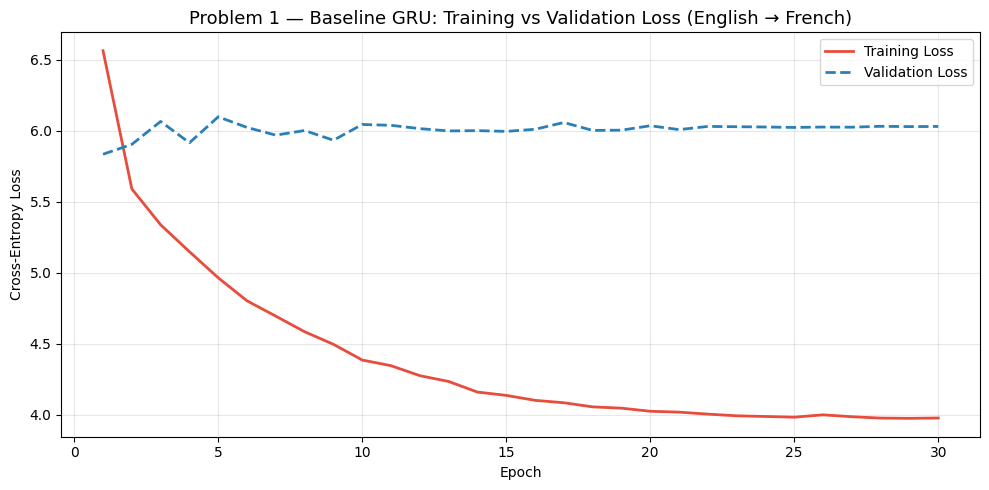

Saved → p1_loss_curves.png


In [32]:
#Plot training and validation loss curves 
fig, ax = plt.subplots(figsize=(10, 5))
epochs  = range(1, EPOCHS_P1 + 1)

ax.plot(epochs, p1_train_losses, label="Training Loss",   color="#e74c3c", linewidth=2)
ax.plot(epochs, p1_val_losses,   label="Validation Loss", color="#2980b9", linewidth=2, linestyle="--")
ax.set_title("Problem 1 — Baseline GRU: Training vs Validation Loss (English → French)",
             fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("p1_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p1_loss_curves.png")


###  Problem 1: Metrics & Qualitative Translation Samples

In [33]:
# Evaluate baseline model on the validation set 
# Reports: (1) Exact Match Accuracy  (2) Corpus BLEU-4  (3) 5 sample translations

p1_acc, p1_bleu = evaluate_model(
    model      = p1_model,
    val_pairs  = val_pairs,
    src_vocab  = eng_vocab,
    tgt_vocab  = fr_vocab,
    attn_model = False,
    n_samples  = 5,
    label      = "Problem 1 — Baseline GRU (English → French)"
)



  Evaluation: Problem 1 — Baseline GRU (English → French)
  SOURCE                         TARGET                    PREDICTED                 MATCH  BLEU
  ----------------------------------------------------------------------------------------------------
  They feed the pigeons in the  Ils nourrissent les pig  veux une une de de de d  FAIL   0
  She practices yoga every mor  Elle pratique le yoga t  veux de de de de de de   FAIL   0
  I enjoy walking in the snow   J'aime marcher dans la   veux fenêtre dans de de  FAIL   0.033
  She loves to wear modern jac  Elle adore porter des v  veux un une de de de de  FAIL   0
  The city bus arrives precise  Le bus de la ville arri  devons de de de de de d  FAIL   0.0215
  ----------------------------------------------------------------------------------------------------

  RESULTS: Problem 1 — Baseline GRU (English → French)
  Traditional Sequence Accuracy : 0.0%  (0/111 exact matches)
  Corpus BLEU-4 Score           : 0.0


---
##  Problem 2 — GRU + Bahdanau Attention: English → French



### Cell 11 — Bahdanau Attention Mechanism & Attention Decoder

In [34]:
# Bahdanau (Additive) Attention 
# At each decoder step t, attention computes a weighted sum of ALL encoder
# hidden states rather than relying on a single fixed context vector.
#
# Score function (Bahdanau):  score(s_t, h_i) = v^T * tanh(W1*s_t + W2*h_i)
# Attention weights:           alpha = softmax(scores)
# Context vector:              c_t  = sum_i(alpha_i * h_i)
#
# This allows the decoder to selectively focus on relevant source words
# at each generation step — addressing the information bottleneck of P1.

class BahdanauAttention(nn.Module):
    """
    Bahdanau (additive) attention.
    Computes a soft alignment between the current decoder state
    and each encoder output.
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.W1    = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W2    = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v     = nn.Linear(hidden_size, 1,           bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden  : (batch, hidden)   — top layer of decoder GRU
        # encoder_outputs : (batch, src_len, hidden)
        dec_h   = decoder_hidden.unsqueeze(1)               # (batch, 1, hidden)
        scores  = self.v(torch.tanh(self.W1(dec_h) + self.W2(encoder_outputs)))
        # scores: (batch, src_len, 1)
        weights = torch.softmax(scores, dim=1)              # (batch, src_len, 1)
        context = (weights * encoder_outputs).sum(dim=1)    # (batch, hidden)
        return context, weights.squeeze(2)                  # weights: (batch, src_len)


# Attention Decoder 
class AttnGRUDecoder(nn.Module):
    """
    GRU Decoder augmented with Bahdanau attention.
    At each step the decoder attends over all encoder outputs to form
    a dynamic context vector before predicting the next word.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers, dropout):
        super().__init__()
        self.attention  = BahdanauAttention(hidden_size)
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)
        # Input to GRU = embedding + context vector
        self.gru        = nn.GRU(embed_dim + hidden_size, hidden_size, n_layers,
                                  batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.fc_out     = nn.Linear(hidden_size * 2 + embed_dim, vocab_size)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, encoder_outputs):
        # tgt_token       : (batch,)
        # hidden          : (n_layers, batch, hidden)
        # encoder_outputs : (batch, src_len, hidden)
        tgt_token = tgt_token.unsqueeze(1)                          # (batch, 1)
        embedded  = self.dropout(self.embedding(tgt_token))         # (batch, 1, embed_dim)

        # Use top decoder layer hidden state for attention
        context, attn_weights = self.attention(hidden[-1], encoder_outputs)
        context = context.unsqueeze(1)                              # (batch, 1, hidden)

        gru_input      = torch.cat([embedded, context], dim=2)      # (batch,1, embed+hidden)
        output, hidden = self.gru(gru_input, hidden)                # (batch,1, hidden)

        # Prediction uses concatenation of output, context, and embedding
        prediction = self.fc_out(
            torch.cat([output.squeeze(1), context.squeeze(1), embedded.squeeze(1)], dim=1)
        )                                                           # (batch, vocab_size)
        return prediction, hidden, attn_weights


#  Seq2Seq with Attention Wrapper 
class Seq2SeqAttn(nn.Module):
    """Full Seq2Seq model with Bahdanau attention in the decoder."""
    def __init__(self, encoder, decoder, tgt_vocab_size):
        super().__init__()
        self.encoder        = encoder
        self.decoder        = decoder
        self.tgt_vocab_size = tgt_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size      = src.shape[0]
        tgt_len         = tgt.shape[1]
        outputs         = torch.zeros(batch_size, tgt_len, self.tgt_vocab_size).to(device)
        all_attn        = []

        enc_outputs, hidden = self.encoder(src)
        dec_input           = tgt[:, 0]

        for t in range(1, tgt_len):
            out, hidden, attn_w = self.decoder(dec_input, hidden, enc_outputs)
            outputs[:, t]        = out
            all_attn.append(attn_w)
            teacher_force = random.random() < teacher_forcing_ratio
            dec_input     = tgt[:, t] if teacher_force else out.argmax(1)

        return outputs, all_attn


#  Instantiate attention model 
p2_encoder = GRUEncoder(eng_vocab.n_words, EMBED_DIM, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(device)
p2_decoder = AttnGRUDecoder(fr_vocab.n_words, EMBED_DIM, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(device)
p2_model   = Seq2SeqAttn(p2_encoder, p2_decoder, fr_vocab.n_words).to(device)

total_params_p2 = sum(p.numel() for p in p2_model.parameters() if p.requires_grad)
print(f"Problem 2 — GRU + Bahdanau Attention Seq2Seq")
print(f"  Encoder params : {sum(p.numel() for p in p2_encoder.parameters()):,}")
print(f"  Decoder params : {sum(p.numel() for p in p2_decoder.parameters()):,}")
print(f"  Total params   : {total_params_p2:,}")


Problem 2 — GRU + Bahdanau Attention Seq2Seq
  Encoder params : 822,400
  Decoder params : 1,904,255
  Total params   : 2,726,655


### Train Problem 2: GRU + Attention (English → French)

In [35]:
EPOCHS_P2 = 30

print("Training Problem 2 — GRU + Bahdanau Attention (English → French)")
print(f"Epochs: {EPOCHS_P2}  |  Hidden: {HIDDEN_SIZE}  |  Embed: {EMBED_DIM}  |  Layers: {N_LAYERS}")
print("="*65)

p2_train_losses, p2_val_losses = train_model(
    model        = p2_model,
    train_loader = e2f_train_loader,
    val_loader   = e2f_val_loader,
    n_epochs     = EPOCHS_P2,
    lr           = 0.001,
    attn_model   = True,
    label        = "P2-Attention"
)

print("\n✅ Problem 2 training complete!")


Training Problem 2 — GRU + Bahdanau Attention (English → French)
Epochs: 30  |  Hidden: 256  |  Embed: 128  |  Layers: 2
  [P2-Attention] Epoch   1/30 | Train Loss: 6.4898 | Val Loss: 5.9018 | Val PPL: 365.69
  [P2-Attention] Epoch   5/30 | Train Loss: 4.2296 | Val Loss: 5.8140 | Val PPL: 334.95
  [P2-Attention] Epoch  10/30 | Train Loss: 2.5646 | Val Loss: 6.0014 | Val PPL: 404.01
  [P2-Attention] Epoch  15/30 | Train Loss: 1.5909 | Val Loss: 6.0658 | Val PPL: 430.86
  [P2-Attention] Epoch  20/30 | Train Loss: 1.2435 | Val Loss: 6.2322 | Val PPL: 508.86
  [P2-Attention] Epoch  25/30 | Train Loss: 1.1054 | Val Loss: 6.2051 | Val PPL: 495.26
  [P2-Attention] Epoch  30/30 | Train Loss: 1.0296 | Val Loss: 6.2306 | Val PPL: 508.07
  Training complete in 33.9s

✅ Problem 2 training complete!


### Cell 13 — Problem 2: Loss Curves & Comparison with Problem 1

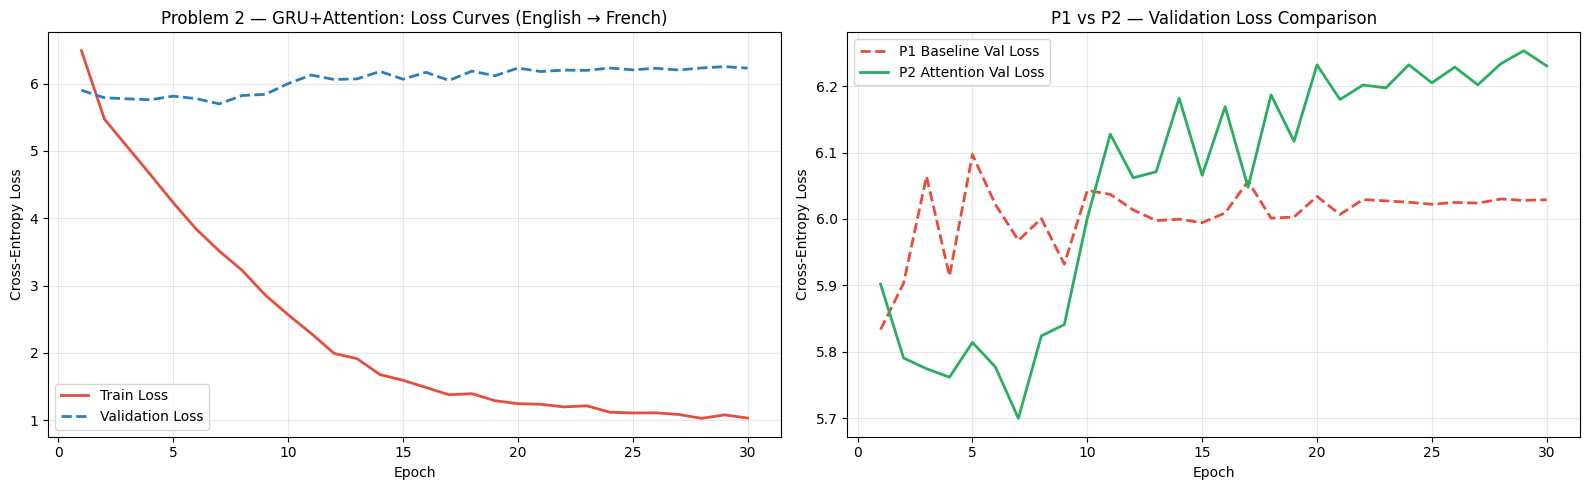

Saved → p2_loss_curves.png


In [36]:
# Plot P2 loss curves alongside P1 for direct comparison 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs = range(1, EPOCHS_P2 + 1)

# Left: P2 standalone curves
ax = axes[0]
ax.plot(epochs, p2_train_losses, label="Train Loss",      color="#e74c3c", linewidth=2)
ax.plot(epochs, p2_val_losses,   label="Validation Loss", color="#2980b9", linewidth=2, linestyle="--")
ax.set_title("Problem 2 — GRU+Attention: Loss Curves (English → French)", fontsize=12)
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Right: P1 vs P2 validation loss overlay
ax = axes[1]
ax.plot(epochs, p1_val_losses, label="P1 Baseline Val Loss",  color="#e74c3c", linewidth=2, linestyle="--")
ax.plot(epochs, p2_val_losses, label="P2 Attention Val Loss", color="#27ae60", linewidth=2)
ax.set_title("P1 vs P2 — Validation Loss Comparison", fontsize=12)
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("p2_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p2_loss_curves.png")


### Problem 2: Metrics, Samples & Attention Map Visualizations

In [37]:
#  Evaluate attention model on validation set 
p2_acc, p2_bleu = evaluate_model(
    model      = p2_model,
    val_pairs  = val_pairs,
    src_vocab  = eng_vocab,
    tgt_vocab  = fr_vocab,
    attn_model = True,
    n_samples  = 5,
    label      = "Problem 2 — GRU+Attention (English → French)"
)

#  Print side-by-side comparison with Problem 1 
print("\n" + "="*55)
print("  COMPARISON: Problem 1 vs Problem 2 (English → French)")
print("="*55)
print(f"  {'Metric':<30} {'P1 Baseline':>12} {'P2 Attention':>12}")
print(f"  {'-'*55}")
print(f"  {'Exact Match Accuracy':<30} {p1_acc*100:>11.2f}% {p2_acc*100:>11.2f}%")
print(f"  {'Corpus BLEU-4 Score':<30} {p1_bleu:>12.4f} {p2_bleu:>12.4f}")
print(f"  {'Final Val Loss':<30} {p1_val_losses[-1]:>12.4f} {p2_val_losses[-1]:>12.4f}")



  Evaluation: Problem 2 — GRU+Attention (English → French)
  SOURCE                         TARGET                    PREDICTED                 MATCH  BLEU
  ----------------------------------------------------------------------------------------------------
  They feed the pigeons in the  Ils nourrissent les pig  nourrissent les dans le  FAIL   0.0699
  She practices yoga every mor  Elle pratique le yoga t  s'entraînent aux techni  FAIL   0
  I enjoy walking in the snow   J'aime marcher dans la   trouve dans dans la dan  FAIL   0.0587
  She loves to wear modern jac  Elle adore porter des v  adore porter des vestes  FAIL   0.3457
  The city bus arrives precise  Le bus de la ville arri  régional arrive à à exa  FAIL   0.0283
  ----------------------------------------------------------------------------------------------------

  RESULTS: Problem 2 — GRU+Attention (English → French)
  Traditional Sequence Accuracy : 0.0%  (0/111 exact matches)
  Corpus BLEU-4 Score           : 0.0415

 

### Attention Weight Visualizations (Alignment Maps)

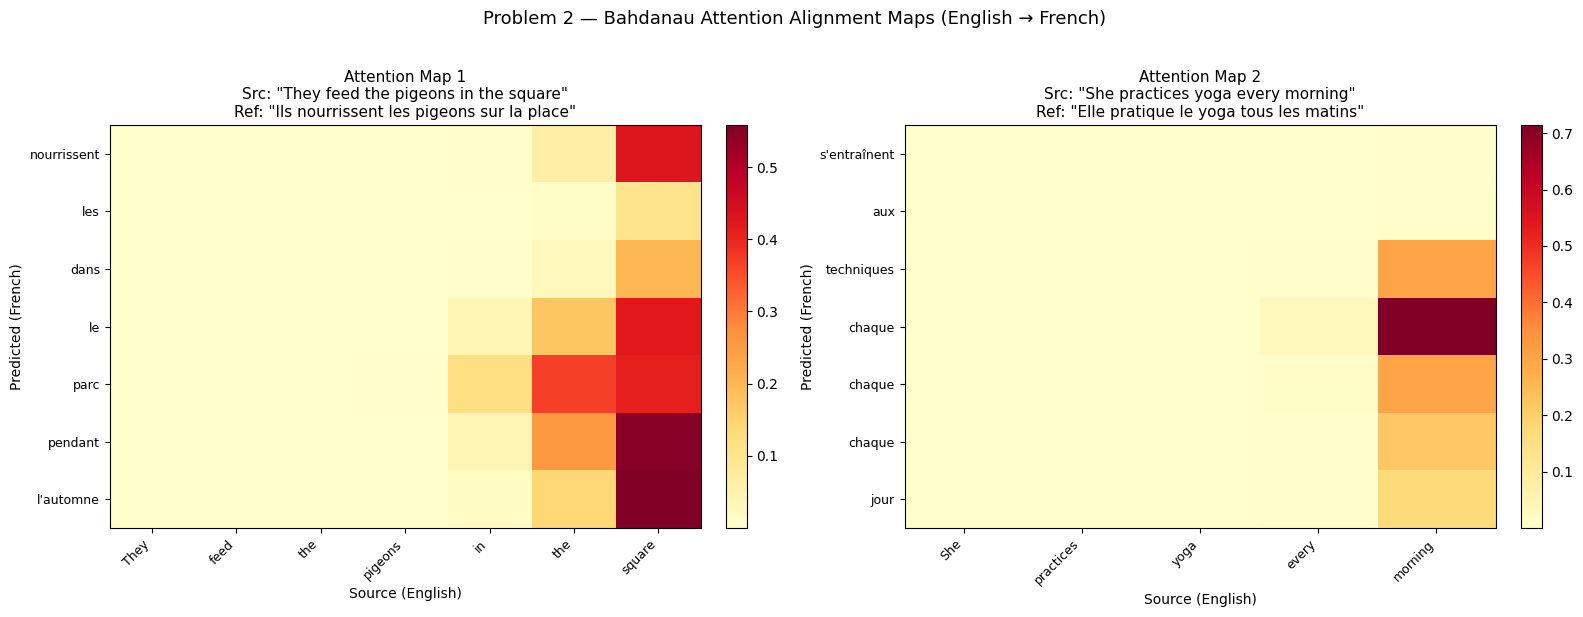

Saved → p2_attention_maps.png


In [38]:
#  Visualize attention alignment maps for 2 validation sentences 
# Each heatmap shows which source (English) words the decoder focused on
# when generating each target (French) word — qualitative evidence of alignment.

def plot_attention(src_sentence, pred_words, attn_weights, title, ax):
    """Plot a single attention heatmap on a given axis."""
    src_words = src_sentence.split()
    matrix    = np.array(attn_weights)          # (tgt_len, src_len+1)
    # Trim to actual source/target word lengths
    matrix    = matrix[:len(pred_words), :len(src_words)]

    im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(src_words)))
    ax.set_xticklabels(src_words, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(pred_words)))
    ax.set_yticklabels(pred_words, fontsize=9)
    ax.set_xlabel("Source (English)", fontsize=10)
    ax.set_ylabel("Predicted (French)", fontsize=10)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


# Pick 2 validation sentences for attention visualization
attn_samples = val_pairs[:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, (src_sent, tgt_sent) in enumerate(attn_samples):
    pred_words, attn_ws = translate(p2_model, src_sent, eng_vocab, fr_vocab, attn_model=True)
    if attn_ws and pred_words:
        plot_attention(src_sent, pred_words, attn_ws,
                       title=f'Attention Map {i+1}\nSrc: "{src_sent}"\nRef: "{tgt_sent}"',
                       ax=axes[i])
    else:
        axes[i].text(0.5, 0.5, "No output generated", ha="center")

plt.suptitle("Problem 2 — Bahdanau Attention Alignment Maps (English → French)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("p2_attention_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p2_attention_maps.png")


---
##  Problem 3 — Reversed Direction: French → English
*The same dataset split is reused but source and target languages are swapped.*  
*Both the baseline GRU (Problem 1) and GRU+Attention (Problem 2) architectures are retrained.*


### French → English Data Setup (same 80/20 split, reversed direction)

In [39]:
#  Reverse the language direction using the same pairs 
# train_pairs and val_pairs are unchanged (same split, same seed).
# We simply swap (eng, fr) → (fr, eng) for source and target.

f2e_train_pairs = [(fr, eng) for eng, fr in train_pairs]
f2e_val_pairs   = [(fr, eng) for eng, fr in val_pairs]

# Build French→English vocabularies
# Source is now French, target is now English
f2e_fr_vocab, f2e_eng_vocab = build_vocabs(
    [(fr, eng) for eng, fr in pairs]
)

print(f"French  (source) vocabulary size : {f2e_fr_vocab.n_words}")
print(f"English (target) vocabulary size : {f2e_eng_vocab.n_words}")

#  Build DataLoaders for French → English 
f2e_train_dataset = TranslationDataset(f2e_train_pairs, f2e_fr_vocab, f2e_eng_vocab)
f2e_val_dataset   = TranslationDataset(f2e_val_pairs,   f2e_fr_vocab, f2e_eng_vocab)

f2e_train_loader  = DataLoader(f2e_train_dataset, batch_size=BATCH_SIZE,
                                shuffle=True, collate_fn=collate_fn)
f2e_val_loader    = DataLoader(f2e_val_dataset,   batch_size=1,
                                shuffle=False, collate_fn=collate_fn)

print(f"F→E Train loader: {len(f2e_train_loader)} batches")
print(f"F→E Val   loader: {len(f2e_val_loader)} batches")


French  (source) vocabulary size : 1151
English (target) vocabulary size : 1025
F→E Train loader: 14 batches
F→E Val   loader: 111 batches


### Train Problem 3A: Baseline GRU (French → English)

In [40]:
EPOCHS_P3 = 30

#  Instantiate fresh baseline model for French→English 
p3_base_encoder = GRUEncoder(f2e_fr_vocab.n_words,  EMBED_DIM, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(device)
p3_base_decoder = GRUDecoder(f2e_eng_vocab.n_words, EMBED_DIM, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(device)
p3_base_model   = Seq2Seq(p3_base_encoder, p3_base_decoder, f2e_eng_vocab.n_words).to(device)

print("Training Problem 3A — Baseline GRU (French → English)")
print("="*65)

p3_base_train_losses, p3_base_val_losses = train_model(
    model        = p3_base_model,
    train_loader = f2e_train_loader,
    val_loader   = f2e_val_loader,
    n_epochs     = EPOCHS_P3,
    lr           = 0.001,
    attn_model   = False,
    label        = "P3-Baseline F→E"
)

print("\n✅ Problem 3A training complete!")


Training Problem 3A — Baseline GRU (French → English)
  [P3-Baseline F→E] Epoch   1/30 | Train Loss: 6.3127 | Val Loss: 5.6417 | Val PPL: 281.95
  [P3-Baseline F→E] Epoch   5/30 | Train Loss: 4.7463 | Val Loss: 5.8286 | Val PPL: 339.88
  [P3-Baseline F→E] Epoch  10/30 | Train Loss: 4.1936 | Val Loss: 5.8310 | Val PPL: 340.72
  [P3-Baseline F→E] Epoch  15/30 | Train Loss: 4.0009 | Val Loss: 5.8980 | Val PPL: 364.30
  [P3-Baseline F→E] Epoch  20/30 | Train Loss: 3.9207 | Val Loss: 5.8974 | Val PPL: 364.07
  [P3-Baseline F→E] Epoch  25/30 | Train Loss: 3.8964 | Val Loss: 5.9135 | Val PPL: 370.00
  [P3-Baseline F→E] Epoch  30/30 | Train Loss: 3.8840 | Val Loss: 5.9080 | Val PPL: 367.97
  Training complete in 20.0s

✅ Problem 3A training complete!


### Cell 18 — Train Problem 3B: GRU + Attention (French → English)

In [41]:
#  Instantiate fresh attention model for French→English 
p3_attn_encoder = GRUEncoder(f2e_fr_vocab.n_words,  EMBED_DIM, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(device)
p3_attn_decoder = AttnGRUDecoder(f2e_eng_vocab.n_words, EMBED_DIM, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(device)
p3_attn_model   = Seq2SeqAttn(p3_attn_encoder, p3_attn_decoder, f2e_eng_vocab.n_words).to(device)

print("Training Problem 3B — GRU+Attention (French → English)")
print("="*65)

p3_attn_train_losses, p3_attn_val_losses = train_model(
    model        = p3_attn_model,
    train_loader = f2e_train_loader,
    val_loader   = f2e_val_loader,
    n_epochs     = EPOCHS_P3,
    lr           = 0.001,
    attn_model   = True,
    label        = "P3-Attention F→E"
)

print("\n✅ Problem 3B training complete!")


Training Problem 3B — GRU+Attention (French → English)
  [P3-Attention F→E] Epoch   1/30 | Train Loss: 6.2748 | Val Loss: 5.8324 | Val PPL: 341.18
  [P3-Attention F→E] Epoch   5/30 | Train Loss: 4.1129 | Val Loss: 5.5636 | Val PPL: 260.76
  [P3-Attention F→E] Epoch  10/30 | Train Loss: 2.2585 | Val Loss: 5.7450 | Val PPL: 312.63
  [P3-Attention F→E] Epoch  15/30 | Train Loss: 1.3713 | Val Loss: 5.8885 | Val PPL: 360.87
  [P3-Attention F→E] Epoch  20/30 | Train Loss: 1.1174 | Val Loss: 5.8955 | Val PPL: 363.41
  [P3-Attention F→E] Epoch  25/30 | Train Loss: 0.9885 | Val Loss: 5.9571 | Val PPL: 386.50
  [P3-Attention F→E] Epoch  30/30 | Train Loss: 0.9474 | Val Loss: 5.9409 | Val PPL: 380.27
  Training complete in 30.3s

✅ Problem 3B training complete!


###  Problem 3: Loss Curves for Both Architectures (French → English)

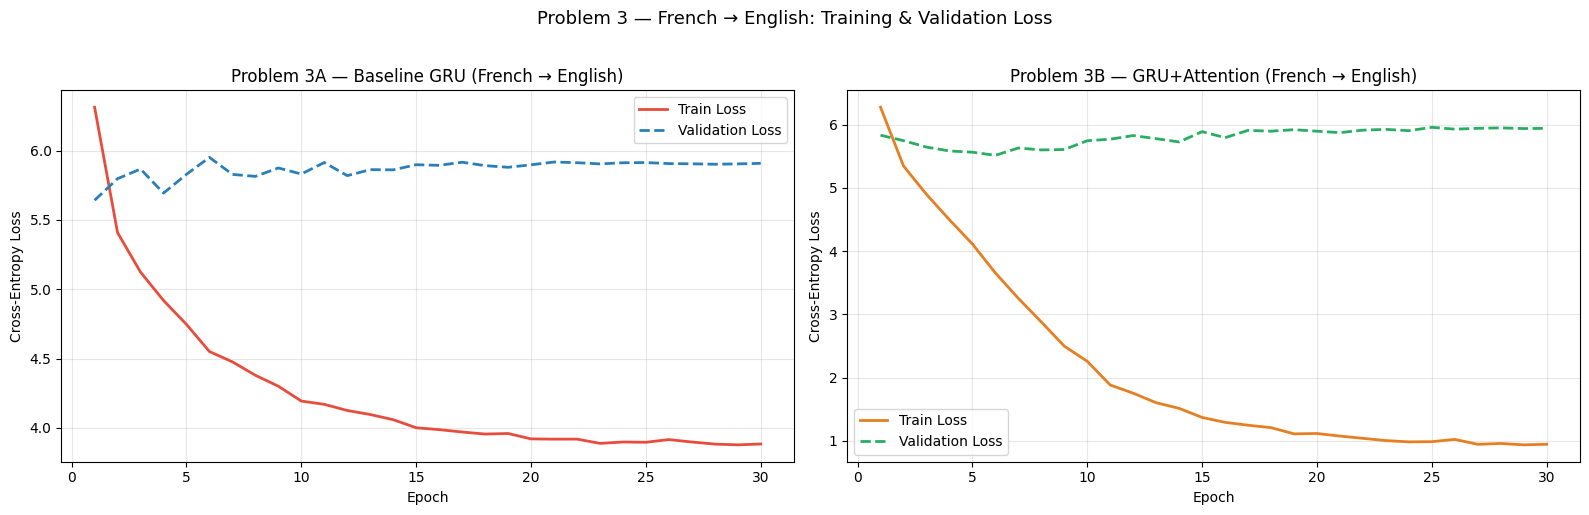

Saved → p3_loss_curves.png


In [42]:
#  Plot all four loss curves together 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs    = range(1, EPOCHS_P3 + 1)

# Baseline F→E
ax = axes[0]
ax.plot(epochs, p3_base_train_losses, label="Train Loss",      color="#e74c3c", linewidth=2)
ax.plot(epochs, p3_base_val_losses,   label="Validation Loss", color="#2980b9", linewidth=2, linestyle="--")
ax.set_title("Problem 3A — Baseline GRU (French → English)", fontsize=12)
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Attention F→E
ax = axes[1]
ax.plot(epochs, p3_attn_train_losses, label="Train Loss",      color="#e67e22", linewidth=2)
ax.plot(epochs, p3_attn_val_losses,   label="Validation Loss", color="#27ae60", linewidth=2, linestyle="--")
ax.set_title("Problem 3B — GRU+Attention (French → English)", fontsize=12)
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Problem 3 — French → English: Training & Validation Loss", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("p3_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p3_loss_curves.png")


###  Problem 3: Metrics & Qualitative Translation Samples

In [43]:
#  Evaluate both French→English models 
p3_base_acc, p3_base_bleu = evaluate_model(
    model      = p3_base_model,
    val_pairs  = f2e_val_pairs,
    src_vocab  = f2e_fr_vocab,
    tgt_vocab  = f2e_eng_vocab,
    attn_model = False,
    n_samples  = 5,
    label      = "Problem 3A — Baseline GRU (French → English)"
)

p3_attn_acc, p3_attn_bleu = evaluate_model(
    model      = p3_attn_model,
    val_pairs  = f2e_val_pairs,
    src_vocab  = f2e_fr_vocab,
    tgt_vocab  = f2e_eng_vocab,
    attn_model = True,
    n_samples  = 5,
    label      = "Problem 3B — GRU+Attention (French → English)"
)



  Evaluation: Problem 3A — Baseline GRU (French → English)
  SOURCE                         TARGET                    PREDICTED                 MATCH  BLEU
  ----------------------------------------------------------------------------------------------------
  Ils nourrissent les pigeons   They feed the pigeons i  need a a a the the       FAIL   0.0411
  Elle pratique le yoga tous l  She practices yoga ever  need a a the the         FAIL   0
  J'aime marcher dans la neige  I enjoy walking in the   built a a a the the      FAIL   0.0408
  Elle adore porter des vestes  She loves to wear moder  need a a a the the       FAIL   0
  Le bus de la ville arrive pr  The city bus arrives pr  need a a a the the       FAIL   0
  ----------------------------------------------------------------------------------------------------

  RESULTS: Problem 3A — Baseline GRU (French → English)
  Traditional Sequence Accuracy : 0.0%  (0/111 exact matches)
  Corpus BLEU-4 Score           : 0.0

  Evaluation: 

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


  ----------------------------------------------------------------------------------------------------

  RESULTS: Problem 3B — GRU+Attention (French → English)
  Traditional Sequence Accuracy : 0.0%  (0/111 exact matches)
  Corpus BLEU-4 Score           : 0.0498


###  Full Cross-Problem Comparison Table

In [44]:
# Print comprehensive results table across all 4 model/direction combos 
print("\n" + "="*75)
print("  FULL RESULTS SUMMARY — All Problems & Directions")
print("="*75)
print(f"  {'Model':<35} {'Direction':<10} {'Exact Acc':>10} {'BLEU-4':>10} {'Val Loss':>10}")
print(f"  {'-'*75}")
print(f"  {'P1 — Baseline GRU':<35} {'EN→FR':<10} {p1_acc*100:>9.2f}% {p1_bleu:>10.4f} {p1_val_losses[-1]:>10.4f}")
print(f"  {'P2 — GRU + Bahdanau Attention':<35} {'EN→FR':<10} {p2_acc*100:>9.2f}% {p2_bleu:>10.4f} {p2_val_losses[-1]:>10.4f}")
print(f"  {'P3A — Baseline GRU':<35} {'FR→EN':<10} {p3_base_acc*100:>9.2f}% {p3_base_bleu:>10.4f} {p3_base_val_losses[-1]:>10.4f}")
print(f"  {'P3B — GRU + Bahdanau Attention':<35} {'FR→EN':<10} {p3_attn_acc*100:>9.2f}% {p3_attn_bleu:>10.4f} {p3_attn_val_losses[-1]:>10.4f}")
print("="*75)



  FULL RESULTS SUMMARY — All Problems & Directions
  Model                               Direction   Exact Acc     BLEU-4   Val Loss
  ---------------------------------------------------------------------------
  P1 — Baseline GRU                   EN→FR           0.00%     0.0000     6.0290
  P2 — GRU + Bahdanau Attention       EN→FR           0.00%     0.0415     6.2306
  P3A — Baseline GRU                  FR→EN           0.00%     0.0000     5.9080
  P3B — GRU + Bahdanau Attention      FR→EN           0.00%     0.0498     5.9409


###  4-Way Validation Loss Comparison (All Models & Directions)

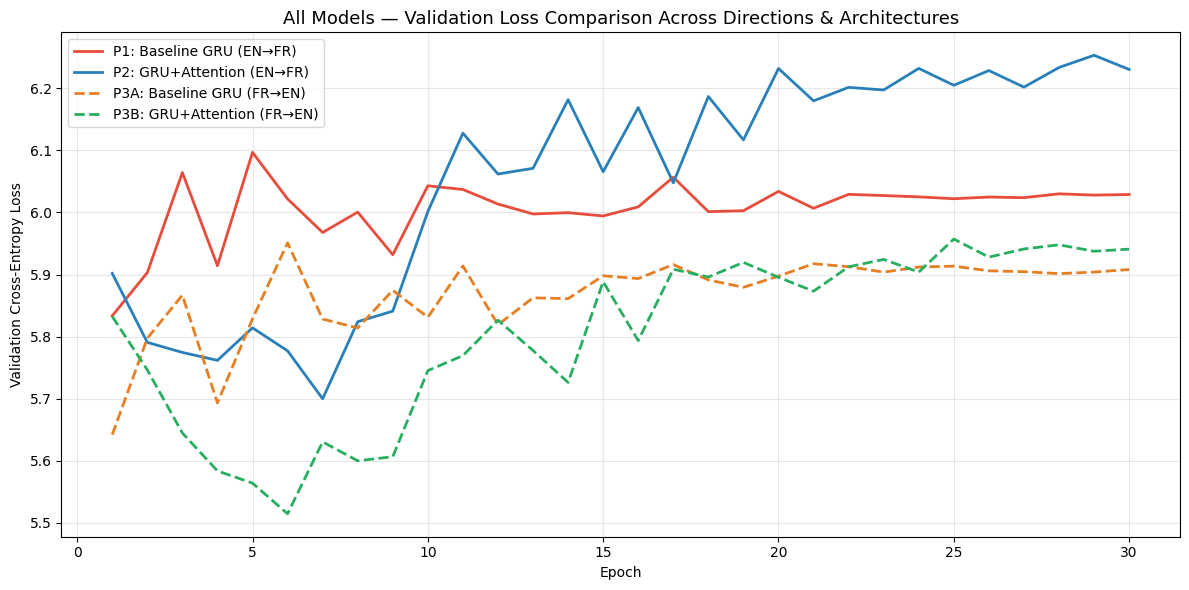

Saved → p3_all_val_loss.png


In [45]:
#  Overlay all four validation loss curves in one plot 
fig, ax = plt.subplots(figsize=(12, 6))
epochs  = range(1, EPOCHS_P3 + 1)

ax.plot(epochs, p1_val_losses,        label="P1: Baseline GRU (EN→FR)",       color="#e74c3c", linewidth=2)
ax.plot(epochs, p2_val_losses,        label="P2: GRU+Attention (EN→FR)",       color="#2980b9", linewidth=2)
ax.plot(epochs, p3_base_val_losses,   label="P3A: Baseline GRU (FR→EN)",       color="#e67e22", linewidth=2, linestyle="--")
ax.plot(epochs, p3_attn_val_losses,   label="P3B: GRU+Attention (FR→EN)",      color="#27ae60", linewidth=2, linestyle="--")

ax.set_title("All Models — Validation Loss Comparison Across Directions & Architectures",
             fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Cross-Entropy Loss")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("p3_all_val_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → p3_all_val_loss.png")
